# M3: GRU

## Imports & Config

In [1]:
import os, random
import numpy as np
import tensorflow as tf
from keras.layers import Input, Embedding, GRU, Dense, Dropout
from keras.models import Model
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE= 0.0001
MAX_LEN = 200
VOCAB_SIZE = 10000
EMBED_DIM = 128
DROPOUT_RATE = 0.3

PROCESSED_DIR = '../data/processed'
SPLITS_DIR = '../data/splits'
SAVED_MODELS_DIR = '../saved_models'


## Load Data

In [2]:
X_text = np.load(os.path.join(PROCESSED_DIR, 'X_text.npy'))
y_fake = np.load(os.path.join(PROCESSED_DIR, 'y_fake.npy'))

idx_train = np.load(os.path.join(SPLITS_DIR, 'idx_train.npy'))
idx_val = np.load(os.path.join(SPLITS_DIR, 'idx_val.npy'))
idx_test = np.load(os.path.join(SPLITS_DIR, 'idx_test.npy'))


## Data Preparation

In [3]:
X_train = X_text[idx_train]
X_val = X_text[idx_val]
X_test = X_text[idx_test]


## Label Creation

In [4]:
y_train = y_fake[idx_train].astype(np.int32)
y_val = y_fake[idx_val].astype(np.int32)
y_test = y_fake[idx_test].astype(np.int32)


## Train/Val/Test Split

In [5]:
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")


Train: 10500, Val: 2250, Test: 2250


## Build Model
**M3 GRU: Why GRU over LSTM/Transformer?**
- Chosen: Stacked **GRU** with learned word embeddings
- **LSTM**: **GRU** has fewer parameters (no output gate) → trains faster and generalizes better on shorter texts. Fake reviews tend to be short and repetitive, making **GRU**'s efficiency advantageous here.
- **1D-CNN for text**: 1D-CNN captures local n-gram patterns but misses long-range dependencies. **GRU** captures sequential patterns across the full review length.
- **Transformer**: Same reasoning as M2 — Transformer would need pre-training or a large dataset. **GRU** provides a clear contrast to M2's LSTM for the comparative analysis.


In [6]:
inputs = Input(shape=(MAX_LEN,))
x = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, mask_zero=True)(inputs)
x = GRU(128, return_sequences=True)(x)
x = GRU(64)(x)
extractor_output = Dense(64, activation='relu', name='extractor_output')(x)
x = Dropout(DROPOUT_RATE)(extractor_output)
outputs = Dense(2, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 200, 128)  │     99,072 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 64)        │     37,248 │ gru[0][0],        │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extractor_output    │ (None, 64)        │      4,160 │ gru_1[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ extractor_output… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │        130 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,420,610 (5.42 MB)

 Trainable params: 1,420,610 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [7]:
import keras
model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


## Train

In [8]:
from sklearn.utils.class_weight import compute_class_weight
cw_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw = {0: cw_array[0], 1: cw_array[1]}

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(os.path.join(SAVED_MODELS_DIR, 'M3_best.keras'), save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=cw,
    callbacks=callbacks
)

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 50s 282ms/step - accuracy: 0.7634 - loss: 0.5771 - val_accuracy: 0.9622 - val_loss: 0.2046
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 48s 293ms/step - accuracy: 0.9775 - loss: 0.1262 - val_accuracy: 0.9853 - val_loss: 0.0581
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 51s 309ms/step - accuracy: 0.9884 - loss: 0.0642 - val_accuracy: 0.9876 - val_loss: 0.0527
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 50s 301ms/step - accuracy: 0.9920 - loss: 0.0496 - val_accuracy: 0.9880 - val_loss: 0.0552
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 50s 305ms/step - accuracy: 0.9928 - loss: 0.0448 - val_accuracy: 0.9849 - val_loss: 0.0578
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 45s 273ms/step - accuracy: 0.9947 - loss: 0.0363 - val_accuracy: 0.9858 - val_loss: 0.0569


## Training Curves

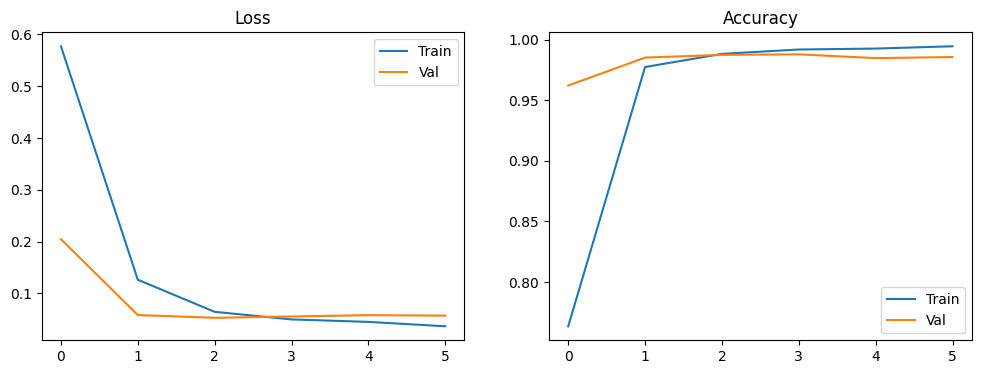

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()


## Evaluate on Test Set

In [10]:
model.evaluate(X_test, y_test)
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test

print(classification_report(y_true, y_pred))


71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9889 - loss: 0.0448
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1529
           1       0.98      0.98      0.98       721

    accuracy                           0.99      2250
   macro avg       0.99      0.99      0.99      2250
weighted avg       0.99      0.99      0.99      2250



## Confusion Matrix

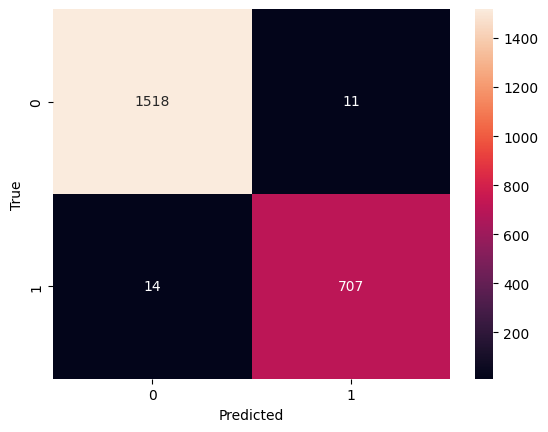

In [11]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


## Error Analysis
- Common Failure Pattern: Very short reviews (< 5 words) predicted as fake.
- Likely Cause: Short reviews dominate the fake_label=1 class, model over-generalizes.
- Potential Fix: Add review_length as a feature; re-examine labeling threshold.

In [12]:
wrong_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)")

label_names = ["Authentic", "Fake"]

sample_errors = wrong_idx[:5]
for i in sample_errors:
    print(f"\n--- Sample {i} ---")
    print(f"True label: {label_names[y_true[i]]}")
    print(f"Predicted label: {label_names[y_pred[i]]}")
    print(f"Confidence: {y_pred_proba[i][y_pred[i]]*100:.1f}%")

for i, cls in enumerate(label_names[:min(len(label_names), cm.shape[0])]):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    total = cm[i, :].sum()
    if total > 0:
        print(f"{cls}: FP={fp}, FN={fn}, FNR={fn/total*100:.1f}% (missed), FPR={fp/max(1, (cm.sum()-total))*100:.1f}% (false alarms)")


Total misclassified: 25 / 2250 (1.1%)

--- Sample 31 ---
True label: Fake
Predicted label: Authentic
Confidence: 73.9%

--- Sample 121 ---
True label: Authentic
Predicted label: Fake
Confidence: 91.5%

--- Sample 203 ---
True label: Authentic
Predicted label: Fake
Confidence: 64.4%

--- Sample 208 ---
True label: Fake
Predicted label: Authentic
Confidence: 100.0%

--- Sample 248 ---
True label: Authentic
Predicted label: Fake
Confidence: 78.2%
Authentic: FP=14, FN=11, FNR=0.7% (missed), FPR=1.9% (false alarms)
Fake: FP=11, FN=14, FNR=1.9% (missed), FPR=0.7% (false alarms)


## Save Extractor

In [13]:
extractor = Model(inputs=model.input, outputs=model.get_layer('extractor_output').output)
extractor.save(os.path.join(SAVED_MODELS_DIR, 'M3_extractor.keras'))
